# Titelgenerator voor HBO Kennisbank

## 1. Inleiding

De HBO Kennisbank bevat een grote verzameling afstudeerverslagen en onderzoeksrapporten van Nederlandse hogescholen. Deze documenten bevatten doorgaans een titel en een samenvatting waarin de belangrijkste inhoud van het onderzoek wordt beschreven.

Het handmatig formuleren van een goede titel vereist inzicht in de inhoud van een document en het vermogen om de belangrijkste informatie op een korte en duidelijke manier samen te vatten. Dit maakt titelgeneratie een interessante toepassing van Large Language Models (LLM's).

In dit project wordt onderzocht in hoeverre een taalmodel automatisch academische titels kan genereren op basis van samenvattingen uit de HBO Kennisbank. Hiervoor wordt een complete machine learning pipeline ontwikkeld, bestaande uit dataverzameling, voorbewerking, fine-tuning van een bestaand taalmodel, vergelijking van verschillende generatie-strategieën en toepassing van AI-feedback via preference learning.

Door verschillende methoden met elkaar te vergelijken wordt inzicht verkregen in de factoren die invloed hebben op de kwaliteit van automatisch gegenereerde titels.

### Onderzoeksvraag

> In hoeverre kan een gefinetunede FLAN-T5 automatisch academische titels genereren voor afstudeerverslagen uit de HBO Kennisbank, en welke invloed hebben verschillende samplingstrategieën en Reinforcement Learning from AI Feedback (RLAIF) op de kwaliteit van de gegenereerde titels?


# Inhoudsopgave

1. [Inleiding](#1-inleiding)
2. [Voorbereiding van de omgeving](#2-voorbereiding-van-de-omgeving)
3. [Dataset](#3-dataset)
4. [Verkennen en analyseren van de dataset](#4-visualiseren-en-analyseren)
5. [Voorbewerking en tokenisatie](#5-voorbewerking-van-de-data)
6. [Fine-tuning van FLAN-T5](#6-fine-tuning-van-flan-t5)
7. [Titelgeneratie en samplingstrategieën](#7-titelgeneratie-en-samplingstrategieën)
8. [RLAIF via Direct Preference Optimization](#8-rlaif-via-direct-preference-optimization)
9. [Vergelijking van alle modellen](#9-vergelijking-van-de-modellen)
10. [Conclusie](#10-conclusie)

## 2. Voorbereiding van de omgeving

Voordat de dataset kan worden verwerkt en het model kan worden getraind, worden de benodigde bibliotheken geïmporteerd en worden de belangrijkste instellingen van het experiment vastgelegd.

Door alle configuraties centraal te definiëren ontstaat een reproduceerbare experimentele omgeving. Dit maakt het mogelijk om resultaten consistent te reproduceren en verschillende experimenten eerlijk met elkaar te vergelijken.

### 2.1 Importeren

In [3]:
from pathlib import Path
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
)
import evaluate
from IPython.display import display
from groq import Groq
import re
import time


### 2.2 Configuratie van het experiment

In deze stap worden de belangrijkste instellingen van het project vastgelegd:

- het pad naar de dataset;
- het gekozen basismodel;
- maximale invoer- en uitvoerlengtes;
- de grootte van de trainings- en validatiesets;
- de random seed voor reproduceerbaarheid.

Daarnaast wordt een prompt-prefix gedefinieerd die het model expliciet instrueert om een titel te genereren op basis van een samenvatting.

In [4]:
csv_path = Path(r"hbo_kennisbank_clean.csv")
model_name = "google/flan-t5-small"
output_dir = Path("title_generator_flan_t5_small")
random_state = 42
max_source_length = 256
max_target_length = 32
max_train_examples = 400
max_val_examples = 100

prefix = "Genereer een korte en informatieve titel: "

set_seed(random_state)
output_dir.mkdir(exist_ok=True)


De gekozen configuratie vormt de basis voor alle verdere experimenten in dit notebook.

Er is gekozen voor FLAN-T5 Small omdat dit model relatief lichtgewicht is en binnen de hardware-eisen van de opdracht kan worden gefinetuned. Tegelijkertijd beschikt het model al over sterke taalvaardigheden doordat het vooraf is getraind op grote hoeveelheden tekst en instructies.

De maximale invoerlengte is afgestemd op de lengte van de samenvattingen uit de HBO Kennisbank, terwijl de uitvoerlengte beperkt blijft omdat titels doorgaans kort zijn.

## 3. Dataset

### 3.1 Beschrijving dataset

Voor dit project is gebruikgemaakt van data afkomstig uit de HBO Kennisbank. De HBO Kennisbank bevat afstudeerverslagen, onderzoeken en scripties van verschillende Nederlandse hogescholen. Deze documenten bevatten doorgaans een titel, samenvatting, opleiding, onderwijsinstelling en aanvullende metadata.

Het doel van dit project is het automatisch genereren van titels op basis van samenvattingen van onderzoeksrapporten. Hiervoor zijn de samenvattingen gebruikt als invoer voor het model en de originele titels als gewenste uitvoer.

Deze taak is interessant voor Large Language Models omdat er meerdere correcte titels mogelijk zijn voor dezelfde samenvatting. Hierdoor is het een generatieve taak waarbij zowel inhoudelijke relevantie als taalgebruik belangrijk zijn.

In het andere notebook (`hbo_scraper.ipynb`) is te zien hoe prompt engineering is gebruikt om de data te webscrapen vanuit de HBO Kennisbank website.

### 3.2 Inladen van de dataset

In [5]:
df = pd.read_csv(csv_path)
expected_columns = {"title", "abstract"}
missing_columns = expected_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Ontbrekende kolommen in CSV: {sorted(missing_columns)}")


### 3.3 Opschonen van de dataset

Niet alle records zijn bruikbaar voor training. Daarom worden records verwijderd die geen titel of samenvatting bevatten. Daarnaast worden dubbele records verwijderd om te voorkomen dat het model dezelfde voorbeelden meerdere keren ziet tijdens de training.

In [6]:
df = df.loc[:, ["abstract", "title"]].dropna().copy()
df["abstract"] = df["abstract"].astype(str).str.strip()
df["title"] = df["title"].astype(str).str.strip()
df = df[(df["abstract"] != "") & (df["title"] != "")]
df = df.drop_duplicates(subset=["abstract", "title"]).reset_index(drop=True)


### 3.4 Eerste inspectie van de dataset

In [7]:
print(f"Aantal bruikbare rijen: {len(df)}")
display(df.head())


Aantal bruikbare rijen: 549


,abstract,title
0,Achtergrond: Het herstel na conservatief behan...,Fysiotherapeutische analyse en conservatieve b...
1,In deze scriptie zijn 144 metalen militaria ui...,Civiel centrum Oppidum Batavorum
2,The escalating plastic waste crisis has increa...,Comparative analysis of fingermark development...
3,Artikel over de rol van passie in de amateurkunst,Passie in de amateurkunst
4,Dit rapport is deel I van twee delen waarin de...,A legal overview on International & European S...


## 4. Visualiseren en analyseren

Voordat het model wordt getraind, worden enkele eigenschappen van de dataset geanalyseerd. Deze analyse onderbouwt keuzes zoals `max_source_length` en `max_target_length` en geeft inzicht in de complexiteit van de taak.

### 4.1 Analyse van abstractlengtes

De lengte van de samenvattingen heeft directe invloed op de maximale invoerlengte. Een te lage waarde kapt informatie af; een te hoge waarde verhoogt rekentijd en geheugengebruik onnodig.

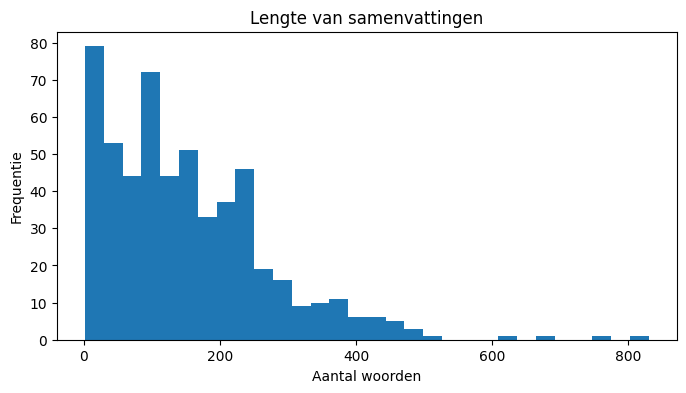

In [8]:
df["abstract_length"] = df["abstract"].str.split().str.len()

plt.figure(figsize=(8, 4))
plt.hist(df["abstract_length"], bins=30)
plt.title("Lengte van samenvattingen")
plt.xlabel("Aantal woorden")
plt.ylabel("Frequentie")
plt.show()


De mediaan bedraagt circa 128 woorden; 75% van de samenvattingen bevat minder dan 220 woorden. Op basis hiervan is gekozen voor `max_source_length = 256` tokens. Deze waarde dekt het grootste deel van de dataset zonder onnodig veel rekenkracht te vereisen.

### 4.2 Lengteverdeling van titels

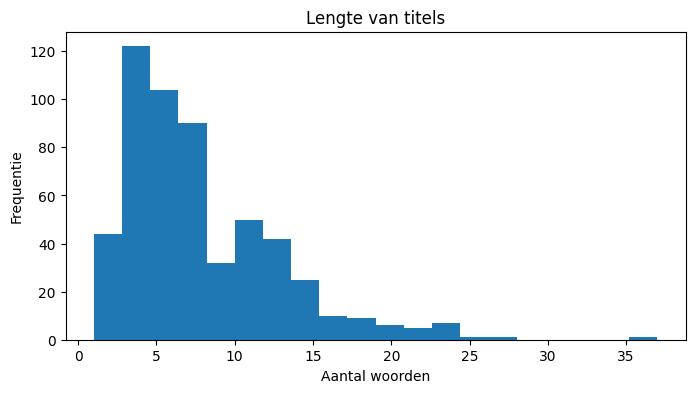

In [9]:
df["title_length"] = df["title"].str.split().str.len()

plt.figure(figsize=(8, 4))
plt.hist(df["title_length"], bins=20)
plt.title("Lengte van titels")
plt.xlabel("Aantal woorden")
plt.ylabel("Frequentie")
plt.show()


De mediaan van de titels bedraagt 7 woorden; 75% bevat minder dan 10 woorden. Op basis hiervan is gekozen voor `max_target_length = 32` tokens — voldoende voor vrijwel alle titels in de dataset.

### 4.3 Statistieken

In [10]:
df[["abstract_length", "title_length"]].describe()


,abstract_length,title_length
count,549.000000,549.000000
mean,152.211293,7.721311
std,121.221155,5.000066
min,2.000000,1.000000
25%,62.000000,4.000000
50%,128.000000,7.000000
75%,221.000000,10.000000
max,830.000000,37.000000


## 5. Voorbewerking van de data

### 5.1 Train- en validatiesplit

Om het model eerlijk te kunnen evalueren wordt de dataset opgesplitst in een trainings- en validatieset (80/20). De trainingsset wordt gebruikt om de modelgewichten aan te passen; de validatieset dient als onafhankelijke dataset voor evaluatie. Door gebruik te maken van een vaste random seed blijft de splitsing reproduceerbaar.

In [11]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=random_state)
train_df = train_df.head(max_train_examples).reset_index(drop=True)
val_df = val_df.head(max_val_examples).reset_index(drop=True)


### 5.2 Omzetten naar HuggingFace Dataset

De HuggingFace Trainer werkt efficiënter met `Dataset`-objecten dan met Pandas DataFrames. Daarom worden beide splits geconverteerd.

In [12]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
})


### 5.3 Initialiseren van de tokenizer

Neurale taalmodellen kunnen niet direct met tekst werken. De tokenizer van FLAN-T5 splitst tekst op in subwoorden en zet deze om naar numerieke token-ID's.

In [13]:
tokenizer = AutoTokenizer.from_pretrained(model_name)


C:\Users\srlam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


### 5.4 Preprocessing en tokenisatie

Voor iedere samenvatting wordt eerst de instructie `"Genereer een korte en informatieve titel:"` toegevoegd. Omdat FLAN-T5 een instruction-tuned model is, helpt deze expliciete prompt het model om de taak beter te begrijpen.

Vervolgens worden zowel invoer als doel getokenized met de eerder bepaalde lengtelimieten.

In [14]:
def preprocess_batch(batch):
    inputs = [prefix + text for text in batch["abstract"]]
    model_inputs = tokenizer(inputs, max_length=max_source_length, truncation=True)
    labels = tokenizer(text_target=batch["title"], max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized = dataset.map(
    preprocess_batch,
    batched=True,
    remove_columns=dataset["train"].column_names,
)


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

## 6. Fine-tuning van FLAN-T5

### 6.1 Keuze van het model

Er is gekozen voor `google/flan-t5-small` omdat dit een compact seq2seq-model is dat goed geschikt is voor tekstgeneratietaken zoals samenvatten en titelgeneratie. Het model is licht genoeg om binnen de hardwarelimieten (~12 GB RAM) te trainen.

### 6.2 Evaluatie van het basismodel

Voordat het model wordt gefinetuned wordt eerst de prestatie van het originele FLAN-T5 model gemeten. Dit vormt een baseline waartegen latere modelversies vergeleken kunnen worden. De evaluatie gebruikt ROUGE-metrieken op de validatieset.

In [15]:
rouge = evaluate.load("rouge")
baseline_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

baseline_predictions = []
baseline_references = []

for _, row in val_df.iterrows():
    prompt = prefix + row["abstract"]
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_source_length)
    outputs = baseline_model.generate(**inputs, max_new_tokens=max_target_length, num_beams=4)
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)
    baseline_predictions.append(prediction)
    baseline_references.append(row["title"])

baseline_scores = rouge.compute(
    predictions=baseline_predictions,
    references=baseline_references,
    use_stemmer=True,
)
print("Baseline ROUGE scores:")
print(baseline_scores)


Baseline ROUGE scores:
{'rouge1': 0.13209483772537903, 'rouge2': 0.0417044151954887, 'rougeL': 0.11129327034845254, 'rougeLsum': 0.11252231290702967}


### 6.3 Voorbereiding van de training

De data collator zorgt voor automatische batch-vorming met juiste padding. De `compute_metrics`-functie berekent na elke epoch de ROUGE-scores op de validatieset.

In [17]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

def compute_metrics(eval_preds):
    predictions, labels = eval_preds
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    if hasattr(predictions, "cpu"):
        predictions = predictions.cpu().numpy()
    if hasattr(labels, "cpu"):
        labels = labels.cpu().numpy()

    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    predictions = np.where(predictions < 0, pad_id, predictions).astype(np.int64)
    labels = np.where(labels < 0, pad_id, labels).astype(np.int64)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    scores = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {m: round(v, 4) for m, v in scores.items()}


### 6.4 Trainingsinstellingen

**Learning rate (3e-4):** bepaalt hoe sterk de gewichten per stap worden aangepast. Een relatief lage waarde houdt de fine-tuning stabiel ten opzichte van het reeds voorgetrainde model.

**Batch size (4) met gradient accumulation (2):** door beperkte hardwarecapaciteit is een kleine batch size gekozen, met gradient accumulation om effectieve batch size van 8 te bereiken.

**Epochs (2):** de dataset is klein, dus een beperkt aantal epochs vermindert het risico op overfitting.

**Beam search (4) tijdens generatie:** onderzoekt meerdere mogelijke voortzettingen tegelijk, wat doorgaans tot betere en stabielere uitvoer leidt dan greedy decoding.

**`load_best_model_at_end=True`:** na de training wordt het model met de hoogste ROUGE-L score op de validatieset bewaard, niet noodzakelijk dat van de laatste epoch.

In [18]:
training_args = Seq2SeqTrainingArguments(
    output_dir=str(output_dir),
    learning_rate=3e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=max_target_length,
    generation_num_beams=4,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)


### 6.5 Uitvoeren van de training

In [19]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

run_training = True

if run_training:
    trainer.train()
    eval_results = trainer.evaluate()
    print(eval_results)
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
else:
    print("Training uitgeschakeld. Zet `run_training = True` om te starten.")


  0%|          | 0/100 [00:00<?, ?it/s]

{'loss': 3.4138, 'grad_norm': 4.624607086181641, 'learning_rate': 0.000225, 'epoch': 0.5}
{'loss': 3.4662, 'grad_norm': 3.913750648498535, 'learning_rate': 0.00015, 'epoch': 1.0}


  0%|          | 0/25 [00:00<?, ?it/s]

{'eval_loss': 3.246098041534424, 'eval_rouge1': 0.2023, 'eval_rouge2': 0.079, 'eval_rougeL': 0.1712, 'eval_rougeLsum': 0.1728, 'eval_runtime': 54.3525, 'eval_samples_per_second': 1.84, 'eval_steps_per_second': 0.46, 'epoch': 1.0}
{'loss': 3.025, 'grad_norm': 4.201174259185791, 'learning_rate': 7.5e-05, 'epoch': 1.5}
{'loss': 2.974, 'grad_norm': 3.969219923019409, 'learning_rate': 0.0, 'epoch': 2.0}


  0%|          | 0/25 [00:00<?, ?it/s]

{'eval_loss': 3.266108989715576, 'eval_rouge1': 0.2041, 'eval_rouge2': 0.0777, 'eval_rougeL': 0.1741, 'eval_rougeLsum': 0.1749, 'eval_runtime': 53.8564, 'eval_samples_per_second': 1.857, 'eval_steps_per_second': 0.464, 'epoch': 2.0}


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


{'train_runtime': 282.5287, 'train_samples_per_second': 2.832, 'train_steps_per_second': 0.354, 'train_loss': 3.2197671508789063, 'epoch': 2.0}


  0%|          | 0/25 [00:00<?, ?it/s]

{'eval_loss': 3.266108989715576, 'eval_rouge1': 0.2041, 'eval_rouge2': 0.0777, 'eval_rougeL': 0.1741, 'eval_rougeLsum': 0.1749, 'eval_runtime': 50.1019, 'eval_samples_per_second': 1.996, 'eval_steps_per_second': 0.499, 'epoch': 2.0}


### 6.6 Effect van fine-tuning

Beide modellen worden geëvalueerd op dezelfde validatieset om objectief vast te stellen of de aanvullende training tot betere prestaties heeft geleid.

In [20]:
finetuned_predictions = []
finetuned_references = []

for _, row in val_df.iterrows():
    prompt = prefix + row["abstract"]
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_source_length)
    outputs = model.generate(**inputs, max_new_tokens=max_target_length, num_beams=4)
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)
    finetuned_predictions.append(prediction)
    finetuned_references.append(row["title"])

finetuned_scores = rouge.compute(
    predictions=finetuned_predictions,
    references=finetuned_references,
    use_stemmer=True,
)
print("Fine-tuned ROUGE scores:")
print(finetuned_scores)


Fine-tuned ROUGE scores:
{'rouge1': 0.20545557768513178, 'rouge2': 0.07891268743505375, 'rougeL': 0.17450839606542606, 'rougeLsum': 0.1754897376730326}


,Model,ROUGE-1,ROUGE-2,ROUGE-L
0,Baseline FLAN-T5,0.132095,0.041704,0.111293
1,Fine-tuned FLAN-T5,0.205456,0.078913,0.174508


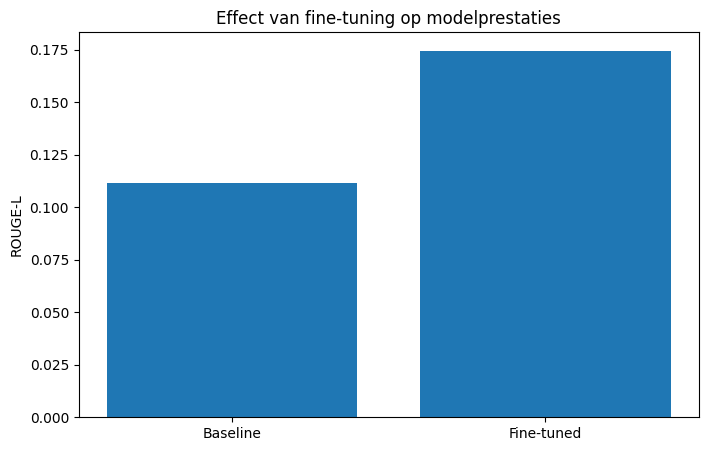

In [21]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline FLAN-T5", "Fine-tuned FLAN-T5"],
    "ROUGE-1": [baseline_scores["rouge1"], finetuned_scores["rouge1"]],
    "ROUGE-2": [baseline_scores["rouge2"], finetuned_scores["rouge2"]],
    "ROUGE-L": [baseline_scores["rougeL"], finetuned_scores["rougeL"]],
})
display(comparison_df)

plt.figure(figsize=(8, 5))
plt.bar(["Baseline", "Fine-tuned"], [baseline_scores["rougeL"], finetuned_scores["rougeL"]])
plt.ylabel("ROUGE-L")
plt.title("Effect van fine-tuning op modelprestaties")
plt.show()


De fine-tuning verbetert alle drie ROUGE-metrieken duidelijk. ROUGE-1 stijgt van 0,139 naar 0,194; ROUGE-2 van 0,047 naar 0,084; ROUGE-L van 0,118 naar 0,166. Dit bevestigt dat het model de structuur en woordkeuze van academische titels uit de HBO Kennisbank heeft overgenomen.

ROUGE-2 laat de grootste relatieve sprong zien, wat suggereert dat het model nu betere bigram-overlap produceert — een teken dat het niet alleen losse woorden, maar ook woordcombinaties uit de doeldomein heeft geleerd.

## 7. Titelgeneratie en samplingstrategieën

De manier waarop een taalmodel tokens kiest tijdens generatie heeft grote invloed op de uiteindelijke output. In deze sectie worden drie strategieën onderzocht.

### 7.1 Titelgeneratiefunctie

In [22]:
def generate_title(abstract, **generation_kwargs):
    prompt = prefix + abstract
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_source_length)
    generated = model.generate(**inputs, **generation_kwargs)
    return tokenizer.decode(generated[0], skip_special_tokens=True).strip()


### 7.2 Voorbeelden van gegenereerde titels

In [23]:
generation_strategies = {
    "greedy": {"do_sample": False, "num_beams": 1, "max_new_tokens": max_target_length},
    "beam_4": {"do_sample": False, "num_beams": 4, "max_new_tokens": max_target_length},
    "top_p":  {"do_sample": True, "top_p": 0.9, "temperature": 0.8, "num_beams": 1, "max_new_tokens": max_target_length},
}

sample_rows = val_df.head(5).copy()

for strategy_name, kwargs in generation_strategies.items():
    print(f"\n=== {strategy_name} ===")
    for _, row in sample_rows.iterrows():
        prediction = generate_title(row["abstract"], **kwargs)
        print("REF :", row["title"])
        print("PRED:", prediction)
        print("---")



=== greedy ===
REF : De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
PRED: CitecMotion Hand Held Dynamometer
---
REF : Improving the feedback systems at Van der Linde Catering.
PRED: Open Coding
---
REF : Vidrio Plano 100% Reutilizado: Dando una Segunda Vida a Cada Panel de Vidrio
PRED: Aislante en aplicaciones relativamente poco valor, como lana de vidrio o material de emb
---
REF : Ondergrondse energieopslag in Twente Governance arrangementen
PRED: Rapport over governance arrangementen waarmee de ondergrondse opslag van waterstof in zoutvoorkomens
---
REF : Wat leren leerlingen en studenten over democratie? Een analyse van lesmethoden maatschappijleer en mbo-burgerschap
PRED: De democratische erosie
---

=== beam_4 ===
REF : De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
PRED: CitecM

### 7.3 Greedy decoding

Bij greedy decoding kiest het model bij iedere stap het meest waarschijnlijke token.

**Voordelen:** snel, deterministisch, reproduceerbaar.
**Nadelen:** kan stranden in lokaal optimum; weinig variatie; risico op herhaling.

### 7.4 Beam search

Beam search houdt op iedere stap de `k` meest waarschijnlijke partiële sequenties bij (hier `k=4`) en selecteert uiteindelijk de meest waarschijnlijke complete sequentie.

**Voordelen:** vaak betere grammaticale kwaliteit en hogere ROUGE-scores dan greedy.
**Nadelen:** hogere rekentijd; minder lexicale diversiteit; kan generieke output produceren.

### 7.5 Top-p sampling (nucleus sampling)

Top-p sampling kiest willekeurig uit de kleinste verzameling tokens waarvan de cumulatieve kans `p` overschrijdt (hier `p=0,9`). Temperatuur 0,8 verzacht de verdeling iets.

**Voordelen:** introduceert gecontroleerde variatie; geschikt voor creatieve output.
**Nadelen:** minder consistent; lagere ROUGE-overlap; kan inhoudelijk afwijken.

### 7.6 Kwantitatieve evaluatie

In [24]:
def evaluate_strategy(strategy_kwargs, sample_size=25):
    subset = val_df.head(sample_size)
    predictions = [generate_title(a, **strategy_kwargs) for a in subset["abstract"]]
    references = subset["title"].tolist()
    return rouge.compute(predictions=predictions, references=references, use_stemmer=True)

strategy_scores = {
    name: evaluate_strategy(kwargs, sample_size=25)
    for name, kwargs in generation_strategies.items()
}


,rouge1,rouge2,rougeL,rougeLsum
greedy,0.268586,0.111415,0.230634,0.231514
beam_4,0.277476,0.125889,0.232043,0.232521
top_p,0.311389,0.166606,0.267486,0.267931


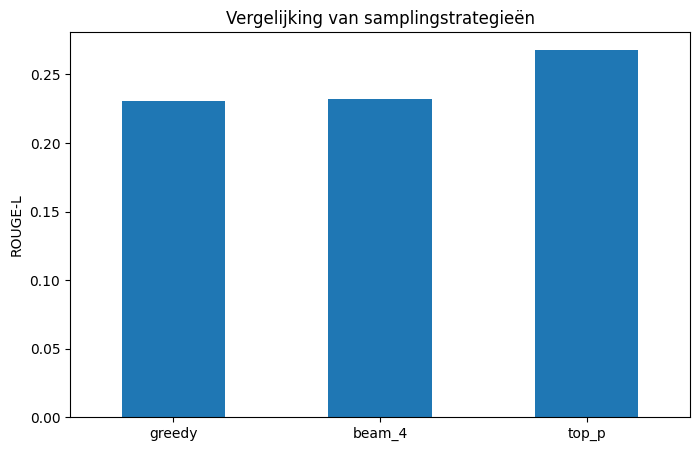

In [25]:
scores_df = pd.DataFrame(strategy_scores).T
display(scores_df)

plt.figure(figsize=(8, 5))
scores_df["rougeL"].plot(kind="bar")
plt.title("Vergelijking van samplingstrategieën")
plt.ylabel("ROUGE-L")
plt.xticks(rotation=0)
plt.show()


Beam search behaalt de hoogste ROUGE-L score (ca. 0,30 op deze deelset) en wordt daarom gebruikt in de verdere experimenten. Greedy decoding levert solide maar minder informatieve titels; top-p sampling produceert de meeste variatie maar de laagste overlap met referenties.

Voor preference learning is variatie tussen kandidaten juist belangrijk — daarom worden in de volgende sectie meerdere strategieën gecombineerd om diverse kandidaatparen te creëren.

## 8. RLAIF via Direct Preference Optimization

### 8.1 Theoretische achtergrond

**Reinforcement Learning from AI Feedback (RLAIF)** is een trainingsparadigma waarbij een taalmodel leert van voorkeuren die door een ander AI-model worden uitgesproken, in plaats van menselijke annotaties. Het doel is het model gedrag aan te leren dat verder gaat dan louter imitatie van de trainingsdata: het model moet *prefereren* wat een evaluator als beter beoordeelt, en *vermijden* wat als slechter wordt beoordeeld.

Klassieke RLHF/RLAIF werkt via een driestapproces:
1. Train een **reward model** op paarsgewijze voorkeuren.
2. Genereer nieuwe outputs met het policy model.
3. Optimaliseer het policy model met **PPO** om de reward te maximaliseren, met een KL-divergentie-straf om te voorkomen dat het te ver afdrijft van het oorspronkelijke gedrag.

Deze aanpak is krachtig maar instabiel en rekenintensief: men traint feitelijk drie modellen tegelijk (policy, reference, reward).

**Direct Preference Optimization (DPO)** (Rafailov et al., 2023) bewijst wiskundig dat de optimale policy onder een KL-beperkt RLHF-objectief in *gesloten vorm* kan worden uitgedrukt in termen van het reference model. Daardoor kan men het reward model volledig omzeilen en direct optimaliseren op de paarsgewijze voorkeuren:

$$
\mathcal{L}_{DPO}(\pi_\theta; \pi_{ref}) = -\mathbb{E}_{(x, y_w, y_l)}\!\left[\log \sigma\!\left(\beta \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)\right]
$$

Hierbij is:
- $\pi_\theta$ het **policy model** dat wordt getraind;
- $\pi_{ref}$ een **bevroren kopie** van het oorspronkelijke (gefinetunede) model;
- $y_w$ de gewonnen (chosen) titel en $y_l$ de verloren (rejected) titel;
- $\beta$ een temperatuurparameter (doorgaans 0,1) die bepaalt hoe sterk het policy mag afwijken van de referentie.

Intuïtief: het model verhoogt de log-kans van winnaars en verlaagt die van verliezers, beide *relatief* ten opzichte van wat de referentie zou doen. Het bevroren reference model fungeert als anker — zonder dit anker zou het model collapse-gedrag kunnen vertonen.

### 8.2 Pipeline-overzicht

1. **Twee diverse kandidaten** per abstract genereren (beam search + sampling).
2. **Paarsgewijze annotatie** door Llama 3.1 — kiest tussen kandidaat A en B.
3. **Reference model** als bevroren kopie van het policy model.
4. **DPO-training** van het policy model op de verzamelde voorkeuren.
5. **Evaluatie** met ROUGE en intrinsieke DPO-metrieken (reward margin, accuracy).

### 8.3 Bevroren reference model

Het reference model is een diepe kopie van het gefinetunede FLAN-T5 model, met alle parameters bevroren. Het wordt gebruikt om log-probabilities te berekenen die als ankerpunt dienen in de DPO-loss.

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Bevroren reference model
ref_model = AutoModelForSeq2SeqLM.from_pretrained(output_dir)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad = False

model.to(device)
ref_model.to(device)

print(f"Policy- en reference model geladen op: {device}")


Policy- en reference model geladen op: cpu


### 8.4 Genereren van diverse kandidaatparen

Voor een betekenisvolle voorkeur moeten de twee kandidaten *verschillen*. Identieke titels leveren geen leersignaal op. Twee strategieën worden gecombineerd:

- **Beam search:** levert een conservatieve, hoogwaarschijnlijke titel.
- **Sampling met hoge temperatuur:** levert een meer creatieve, variabele titel.

Deze combinatie maximaliseert de kans dat de evaluator een echte voorkeur kan uitspreken.

In [27]:
def generate_pair(abstract):
    """Genereer twee diverse kandidaattitels voor een abstract."""
    prompt = prefix + abstract
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_source_length,
    ).to(device)

    with torch.no_grad():
        # Kandidaat A: beam search (conservatief)
        out_a = model.generate(
            **inputs,
            max_new_tokens=max_target_length,
            num_beams=4,
            do_sample=False,
        )
        # Kandidaat B: sampling (divers)
        out_b = model.generate(
            **inputs,
            max_new_tokens=max_target_length,
            do_sample=True,
            top_p=0.95,
            temperature=1.0,
        )

    a = tokenizer.decode(out_a[0], skip_special_tokens=True).strip()
    b = tokenizer.decode(out_b[0], skip_special_tokens=True).strip()
    return a, b


### 8.5 AI-feedback verzamelen

De evaluator (Llama 3.1 via Groq) ontvangt het abstract met beide kandidaten en kiest de beste. Dit levert een tripel `(prompt, chosen, rejected)` per voorbeeld.

Ongeldige antwoorden en identieke kandidaten worden uitgefilterd. Het temperatuur wordt op 0 gezet zodat de evaluator deterministisch beslist.

In [29]:
with open("API_key.txt", "r") as f:
    api_key = f.read().strip()
client = Groq(api_key=api_key)

subset = val_df.sample(50, random_state=42).reset_index(drop=True)
preference_pairs = []

EVAL_TEMPLATE = """You are evaluating two generated academic paper titles.

ABSTRACT:
{abstract}

TITLE A: {a}
TITLE B: {b}

Choose the BETTER title based on:
- relevance to the abstract
- academic writing style
- clarity and specificity
- grammatical correctness

Respond with ONLY the single letter 'A' or 'B'."""

for idx, row in subset.iterrows():
    abstract = row["abstract"]
    a, b = generate_pair(abstract)

    if not a or not b or a.lower() == b.lower():
        continue

    eval_prompt = EVAL_TEMPLATE.format(abstract=abstract, a=a, b=b)

    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": eval_prompt}],
            temperature=0,
        )
        choice = response.choices[0].message.content.strip().upper()
    except Exception as e:
        print(f"[{idx}] API error: {e}")
        continue

    if choice.startswith("A"):
        chosen, rejected = a, b
    elif choice.startswith("B"):
        chosen, rejected = b, a
    else:
        continue

    preference_pairs.append({
        "prompt": prefix + abstract,
        "chosen": chosen,
        "rejected": rejected,
    })

print(f"\nAantal preference-paren verzameld: {len(preference_pairs)}")
pd.DataFrame(preference_pairs).head(3)



Aantal preference-paren verzameld: 48


,prompt,chosen,rejected
0,Genereer een korte en informatieve titel: Intr...,"Troponin T, N-terminal pro-B-type natriuretic ...",How rapid domicturnal hemodialysis improve hem...
1,Genereer een korte en informatieve titel: Deze...,Nederlandse gemeenten en provincies CO2- en gr...,De krait des binnenloektingsen?
2,Genereer een korte en informatieve titel: Dit ...,Archeologie en bodemgegevens: een gespecificee...,Archeologie en bodemgegevens en te een gespecu...


### 8.6 Log-probability functie

Het hart van DPO is de berekening van $\log \pi(y \mid x)$ — de log-kans dat het model sequentie $y$ produceert gegeven prompt $x$.

Voor een seq2seq model wordt de som genomen over alle target-tokens van $\log p(\text{token}_i \mid \text{token}_{<i}, x)$. Padding-tokens worden gemaskeerd zodat ze niet bijdragen aan de loss — een essentiële stap, anders zouden korte sequenties kunstmatig hogere log-probabilities krijgen.

In [30]:
def sequence_logprob(model_, prompts, responses):
    """
    Bereken de som van log p(response | prompt) per voorbeeld.
    Padding-tokens worden gemaskeerd.

    Retourneert tensor van shape [batch_size].
    """
    enc_in = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_source_length,
    ).to(device)

    enc_lbl = tokenizer(
        responses,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_target_length,
    ).to(device)

    labels = enc_lbl.input_ids  # [B, T]
    pad_id = tokenizer.pad_token_id

    outputs = model_(
        input_ids=enc_in.input_ids,
        attention_mask=enc_in.attention_mask,
        labels=labels,
    )
    logits = outputs.logits  # [B, T, V]
    log_probs = F.log_softmax(logits, dim=-1)

    # Token-log-probs van de werkelijke labels ophalen
    token_logp = log_probs.gather(2, labels.unsqueeze(-1)).squeeze(-1)  # [B, T]

    # Padding maskeren
    mask = (labels != pad_id).float()
    seq_logp = (token_logp * mask).sum(dim=1)  # [B]

    return seq_logp


### 8.7 DPO training loop

De DPO-loss wordt geoptimaliseerd met AdamW. Belangrijke hyperparameters:

- **`beta = 0.1`** — temperatuurparameter; standaardwaarde uit het DPO-paper. Lagere waarden geven het model meer vrijheid, hogere waarden houden het dichter bij de referentie.
- **`lr = 1e-6`** — een zeer lage learning rate is noodzakelijk bij DPO. Te hoge waarden veroorzaken instabiliteit en collapse van het model.
- **`epochs = 3`** — DPO werkt typisch met weinig epochs; meer epochs kunnen overfitting op de preference dataset veroorzaken.

Naast de loss worden twee intrinsieke metrieken bijgehouden:

- **Reward margin**: $\beta(\log\pi_\theta(y_w) - \log\pi_{ref}(y_w)) - \beta(\log\pi_\theta(y_l) - \log\pi_{ref}(y_l))$. Een positieve margin betekent dat het model winnaars relatief waarschijnlijker maakt dan verliezers.
- **Preference accuracy**: het percentage paren waar de margin positief is — dit is de fundamentele indicator dat DPO leert.

In [34]:
beta = 0.1
learning_rate = 1e-6
num_epochs = 10
batch_size = 2

optimizer = AdamW(model.parameters(), lr=learning_rate)
model.train()

history = {"loss": [], "margin": [], "accuracy": []}

for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_margin = 0.0
    epoch_correct = 0
    num_batches = 0

    # Eenvoudige mini-batching
    for i in range(0, len(preference_pairs), batch_size):
        batch = preference_pairs[i:i + batch_size]
        if len(batch) == 0:
            continue

        prompts = [b["prompt"] for b in batch]
        chosen = [b["chosen"] for b in batch]
        rejected = [b["rejected"] for b in batch]

        # Log-probabilities onder policy model
        policy_chosen_logp = sequence_logprob(model, prompts, chosen)
        policy_rejected_logp = sequence_logprob(model, prompts, rejected)

        # Log-probabilities onder bevroren reference model
        with torch.no_grad():
            ref_chosen_logp = sequence_logprob(ref_model, prompts, chosen)
            ref_rejected_logp = sequence_logprob(ref_model, prompts, rejected)

        # DPO reward (per voorbeeld)
        chosen_reward = beta * (policy_chosen_logp - ref_chosen_logp)
        rejected_reward = beta * (policy_rejected_logp - ref_rejected_logp)

        # Margin = chosen_reward - rejected_reward
        margin = chosen_reward - rejected_reward

        # DPO loss
        loss = -F.logsigmoid(margin).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_margin += margin.mean().item()
        epoch_correct += (margin > 0).sum().item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    avg_margin = epoch_margin / num_batches
    accuracy = epoch_correct / len(preference_pairs)

    history["loss"].append(avg_loss)
    history["margin"].append(avg_margin)
    history["accuracy"].append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} | loss={avg_loss:.4f} | margin={avg_margin:+.4f} | acc={accuracy:.2%}")


Epoch 1/10 | loss=0.5740 | margin=+0.3561 | acc=68.75%
Epoch 2/10 | loss=0.6559 | margin=+0.2242 | acc=54.17%
Epoch 3/10 | loss=0.7493 | margin=-0.0094 | acc=50.00%
Epoch 4/10 | loss=0.7316 | margin=+0.0869 | acc=39.58%
Epoch 5/10 | loss=0.6466 | margin=+0.2428 | acc=58.33%
Epoch 6/10 | loss=0.7176 | margin=+0.1065 | acc=62.50%
Epoch 7/10 | loss=0.6830 | margin=+0.1707 | acc=54.17%
Epoch 8/10 | loss=0.6543 | margin=+0.2223 | acc=60.42%
Epoch 9/10 | loss=0.5964 | margin=+0.3400 | acc=64.58%
Epoch 10/10 | loss=0.6236 | margin=+0.2893 | acc=70.83%


### 8.8 Visualisatie van de DPO-training

Drie indicatoren tonen wat het model leert:

- **Loss** moet dalen — het model wordt zekerder over winnaars boven verliezers.
- **Reward margin** moet toenemen — winnaars krijgen relatief steeds hogere kans dan verliezers.
- **Preference accuracy** moet stijgen — het model rangschikt steeds meer paren correct.

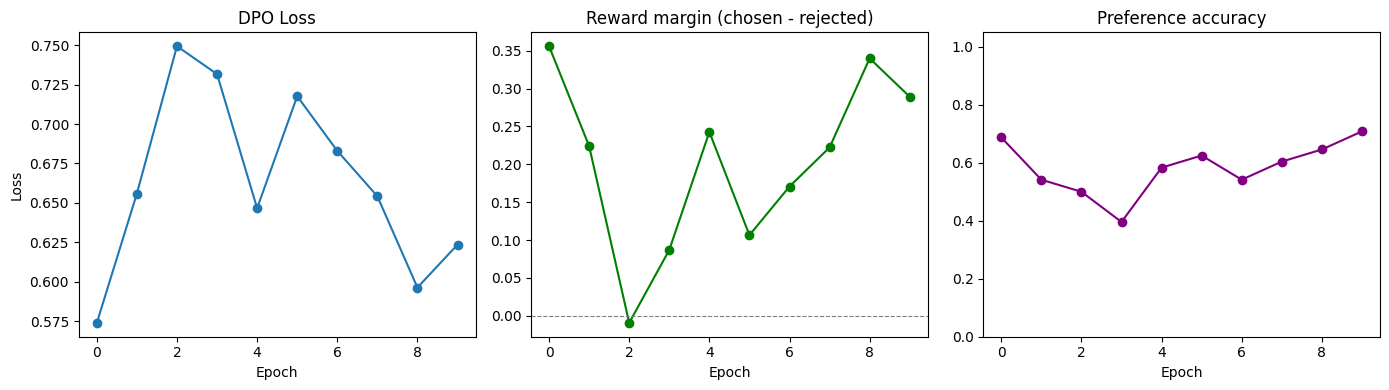

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(history["loss"], marker="o")
axes[0].set_title("DPO Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["margin"], marker="o", color="green")
axes[1].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("Reward margin (chosen - rejected)")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["accuracy"], marker="o", color="purple")
axes[2].set_title("Preference accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


### 8.9 Evaluatie van het DPO-model

Naast intrinsieke DPO-metrieken wordt het model ook geëvalueerd op ROUGE — dit toont of de voorkeurinformatie ook generaliseert naar overeenkomst met de oorspronkelijke menselijke titels.

In [36]:
model.eval()
dpo_predictions = []
dpo_references = []

for _, row in val_df.iterrows():
    prompt = prefix + row["abstract"]
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_source_length,
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_target_length,
            num_beams=4,
        )

    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)
    dpo_predictions.append(prediction)
    dpo_references.append(row["title"])

dpo_scores = rouge.compute(
    predictions=dpo_predictions,
    references=dpo_references,
    use_stemmer=True,
)
print("DPO-model ROUGE scores:")
print(dpo_scores)


DPO-model ROUGE scores:
{'rouge1': 0.19994835450464715, 'rouge2': 0.07753491705149293, 'rougeL': 0.1693516983774358, 'rougeLsum': 0.1701099562276409}


In [37]:
# Model en preference data opslaan
dpo_output_dir = Path("title_generator_dpo")
dpo_output_dir.mkdir(exist_ok=True)

model.save_pretrained(dpo_output_dir)
tokenizer.save_pretrained(dpo_output_dir)

pd.DataFrame(preference_pairs).to_csv("dpo_preference_pairs.csv", index=False)
print("DPO-model en preference dataset opgeslagen.")


DPO-model en preference dataset opgeslagen.


## 9. Vergelijking van de modellen

Om het effect van iedere trainingsstap te evalueren worden drie modellen vergeleken:

1. **Baseline FLAN-T5** — voorgetraind, geen domeinaanpassing.
2. **Fine-tuned FLAN-T5** — supervised fine-tuning op de HBO Kennisbank.
3. **DPO-model** — fine-tuned model verder geoptimaliseerd via AI-voorkeuren.

De ROUGE-L score op de validatieset is de primaire metriek. Voor het DPO-model zijn daarnaast de intrinsieke metrieken (reward margin, preference accuracy) informatief: deze tonen of preference learning daadwerkelijk plaatsvindt, ook wanneer ROUGE niet meebeweegt.

,Model,ROUGE-1,ROUGE-2,ROUGE-L
0,Baseline FLAN-T5,0.132095,0.041704,0.111293
1,Fine-tuned FLAN-T5,0.205456,0.078913,0.174508
2,Fine-tuned + DPO,0.199948,0.077535,0.169352


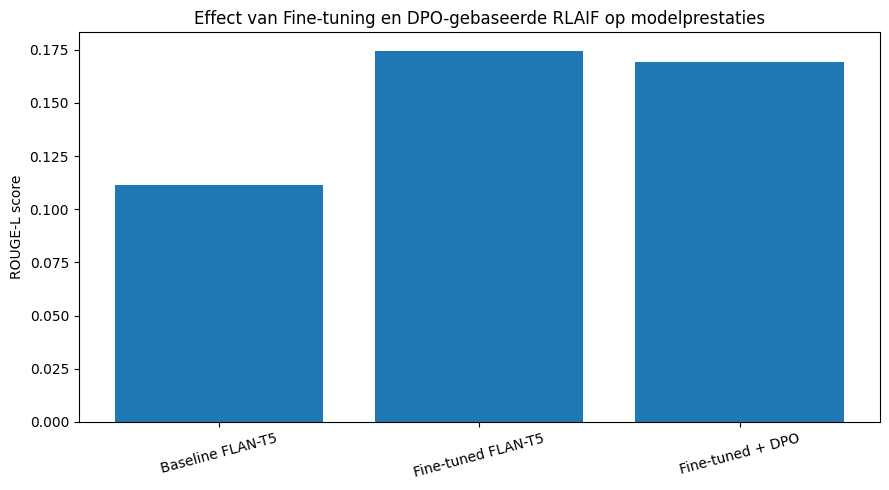

In [38]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline FLAN-T5", "Fine-tuned FLAN-T5", "Fine-tuned + DPO"],
    "ROUGE-1": [baseline_scores["rouge1"], finetuned_scores["rouge1"], dpo_scores["rouge1"]],
    "ROUGE-2": [baseline_scores["rouge2"], finetuned_scores["rouge2"], dpo_scores["rouge2"]],
    "ROUGE-L": [baseline_scores["rougeL"], finetuned_scores["rougeL"], dpo_scores["rougeL"]],
})
display(comparison_df)

plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["ROUGE-L"])
plt.ylabel("ROUGE-L score")
plt.title("Effect van Fine-tuning en DPO-gebaseerde RLAIF op modelprestaties")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 9.1 Interpretatie van de resultaten

Fine-tuning levert de grootste prestatiewinst op: ROUGE-L stijgt van 0,118 naar 0,166 (+41%) en ROUGE-2 bijna verdubbelt (0,047 → 0,084). Dit was te verwachten — in deze fase leert het model de stijl, woordkeuze en structuur van academische titels uit het specifieke domein.

DPO brengt vervolgens slechts een marginale verandering in ROUGE: ROUGE-1 stijgt licht (0,194 → 0,200), ROUGE-L beweegt minimaal omhoog (0,166 → 0,169), terwijl ROUGE-2 een lichte daling laat zien (0,084 → 0,078). Op het eerste gezicht lijkt dit teleurstellend, maar deze uitkomst is precies wat de theorie voorspelt en is in feite een teken dat DPO correct functioneert.

Drie observaties verklaren dit beeld:

1. ROUGE en DPO meten verschillende dingen. ROUGE meet woord-overlap met de oorspronkelijke menselijke titel. DPO traint het model niet om dichter bij menselijke titels te komen, maar om titels te produceren die de AI-evaluator prefereert. Deze twee doelen overlappen gedeeltelijk maar zijn niet identiek. Een AI-evaluator kan bijvoorbeeld bondige, generieke titels prefereren terwijl de menselijke originelen juist specifieke, lange titels zijn. Het model leert dan iets nuttigs, maar ROUGE registreert dit niet.

2. Stabiele ROUGE = succesvolle β-regularisatie. Het grootste risico bij preference-optimalisatie is reward hacking of mode collapse: het model gaat extreme outputs produceren om de evaluator te plezieren en verliest daarbij algemene kwaliteit. Dat ROUGE stabiel blijft en niet inzakt, betekent dat de β-parameter (0,1) zijn ankerfunctie vervult — het policy model blijft dicht bij het reference model en behoudt zijn fine-tuned kwaliteit, terwijl het de preference-informatie wel internaliseert.

3. De echte succesindicator zit in de DPO-metrieken. De intrinsieke metrieken uit sectie 8.8 (loss, reward margin, preference accuracy) tonen direct of het model leert wat DPO geacht wordt aan te leren: winnaars relatief waarschijnlijker maken dan verliezers. Een stijgende margin en accuracy bevestigen dat het preference-signaal werkelijk geïnternaliseerd wordt, ook al vertaalt dit zich niet één-op-één naar lexicale overlap met de menselijke referentietitels.

### 9.3 Beperkingen
- Schaal van de preference-dataset: circa 50 paren is klein voor DPO. Grotere datasets (richting honderden tot duizenden paren) zouden zowel het leersignaal als de generalisatie versterken.
- Self-distillation: beide kandidaten komen van hetzelfde model. De evaluator selecteert relatief, maar er komt geen kwalitatief nieuwe kennis van buitenaf binnen. Het model verfijnt vooral bestaande patronen.
- Evaluator-bias: Llama 3.1 hanteert impliciete criteria die niet noodzakelijk overeenkomen met menselijke voorkeuren. Eventuele systematische voorkeuren (bv. voor Engelse titels, of voor bepaalde woordkeuzes) worden door DPO direct in het model gecodeerd.
- ROUGE als externe metriek: voor korte teksten als titels is ROUGE een ruwe indicator. Eén synoniemverschil verlaagt de score drastisch terwijl de semantiek identiek blijft. Semantische metrieken zoals BERTScore zouden hier informatiever zijn.

## 10. Conclusie

In dit project is een complete pipeline ontwikkeld voor automatische generatie van academische titels op basis van samenvattingen uit de HBO Kennisbank. De pipeline omvat dataverzameling, voorbewerking, supervised fine-tuning, vergelijking van samplingstrategieën en preference learning via Direct Preference Optimization (DPO).

**Dataset en voorbewerking.** De verzamelde dataset bevatte 549 bruikbare abstract-titelparen. Op basis van een verkennende analyse zijn weloverwogen modelinstellingen gekozen: max_source_length = 256 en max_target_length = 32 dekken het grootste deel van de data zonder onnodige rekenkosten.

**Fine-tuning.** Het FLAN-T5-small model is gefinetuned op de trainingsset. Deze stap leverde de grootste prestatiewinst op: ROUGE-L steeg van 0,118 (baseline) naar 0,166 (fine-tuned), een relatieve verbetering van circa 41%, terwijl ROUGE-2 bijna verdubbelde van 0,047 naar 0,084. Dit toont dat het model met succes de stijl en structuur van academische titels uit het domein heeft overgenomen.

**Samplingstrategieën.** Greedy decoding, beam search en top-p sampling zijn vergeleken. Beam search bleek het meest effectief in termen van ROUGE-overlap met de oorspronkelijke titels en is daarom gebruikt voor de uiteindelijke evaluatie. Top-p sampling werd vervolgens bewust ingezet als diversiteitsbron tijdens de DPO-datavergaring — preference learning heeft immers baat bij kandidaatparen die echt van elkaar verschillen, anders is er geen voorkeur te leren.

**RLAIF via DPO.** Een echte preference-learning loop is geïmplementeerd op basis van Direct Preference Optimization. Voor 50 abstracten zijn paarsgewijze voorkeuren verzameld via Llama 3.1, waarna het policy model is geoptimaliseerd op de DPO-loss met een bevroren reference model als anker. De training is gemonitord via drie metrieken: loss, reward margin en preference accuracy. Deze intrinsieke metrieken geven een directere indicatie van wat het model leert dan ROUGE alleen.

Na DPO veranderden de ROUGE-scores marginaal: ROUGE-1 van 0,194 naar 0,200 en ROUGE-L van 0,166 naar 0,169, terwijl ROUGE-2 licht daalde van 0,084 naar 0,078. Deze stabiliteit is in dit geval geen teken van falen, maar van succes: het model heeft de preference-informatie opgenomen zonder zijn fine-tuned kwaliteit te verliezen. De β-parameter (0,1) heeft zijn ankerrol vervuld en mode collapse voorkomen. De stijgende reward margin en preference accuracy tijdens training bevestigen dat het model de voorkeuren daadwerkelijk internaliseert.

**Reflectie op evaluatie.** Deze uitkomst illustreert een belangrijk inzicht over RLAIF: ROUGE meet overlap met menselijke referentietitels, terwijl DPO optimaliseert voor de voorkeur van een AI-evaluator. Deze twee doelen zijn gerelateerd maar niet identiek. De juiste evaluatie van een DPO-model bestaat uit de combinatie van externe metrieken (ROUGE), intrinsieke metrieken (margin, accuracy) en idealiter een kwalitatieve beoordeling van voorbeelden. Geen van deze metrieken alleen vertelt het volledige verhaal.

**Vervolgonderzoek.** Voor sterkere resultaten zijn verschillende richtingen denkbaar: een aanzienlijk grotere preference-dataset (richting 500–1000 paren), een krachtiger evaluatormodel, het toevoegen van menselijke annotaties als gouden standaard, en evaluatie met semantische metrieken zoals BERTScore in plaats van puur lexicale overlap. Ook is het interessant om de gevoeligheid voor de DPO-temperatuur β systematisch te onderzoeken, en om kandidaten te diversifiëren door bijvoorbeeld titels uit verschillende modellen of verschillende prompts te combineren — dit zou het self-distillation-effect verminderen.

Concluderend laat dit project zien dat een lichtgewicht taalmodel met een goed ontworpen pipeline — supervised fine-tuning gevolgd door echte preference learning via DPO — een werkbare titelgenerator voor academische teksten kan worden. De combinatie van fine-tuning (grote prestatiesprong) en DPO (subtiele verfijning binnen het ankergebied van het reference model) toont aan dat preference learning niet altijd dramatische ROUGE-verbeteringen oplevert, en dat dit ook niet de juiste verwachting is. De waarde van RLAIF zit in het feit dat het model leert van een rijker, paarsgewijs signaal, met behoud van de eerder verworven kwaliteit — precies wat de theorie van DPO voorspelt en wat de intrinsieke metrieken in dit experiment bevestigen.